In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import gymnasium as gym

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

from highway.scripts.environment import get_env, ConfigType
from highway.scripts.run import eval_agent, run_one_episode

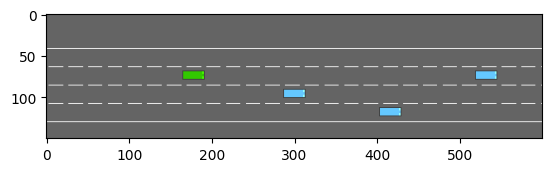

In [2]:
env = get_env(seed=1, config_type=ConfigType.SHARED_CORE)
# Show the environment
plt.imshow(env.render())
plt.show()

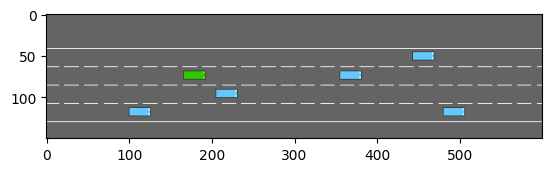

Episode length: 30


In [10]:
obs, _ = env.reset(seed=1)
done = False
length = 0
while not done: 
    action = env.unwrapped.action_type.actions_indexes["IDLE"]
    obs, reward, terminated, truncated, info = env.step(action)
    
    length += 1
    done = terminated or truncated

    clear_output(wait=True) 
    plt.imshow(env.render())
    plt.show()
print("Episode length:", length)

## Baseline: Random Agent

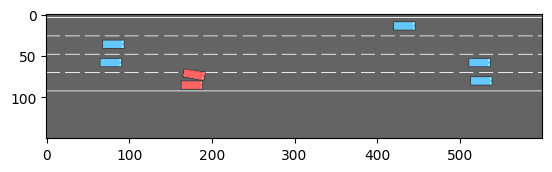

Episode reward=13.54, length=18
Average over 5 runs : 7.33 with average length 10.60


In [3]:
from highway.models.random_agent.random_agent import RandomAgent

agent = RandomAgent(env.observation_space, env.action_space)
    
run_one_episode(env, agent, display=True)
rewards, lengths = eval_agent(env, agent, n_sim=5)
print(f'Average over 5 runs : {np.mean(rewards):.2f} with average length {np.mean(lengths):.2f}')

## DQN Agent

In [ ]:
from highway.models.dqn.mlp import QNetwork
network = QNetwork(10, 5, 5)
print("Nb of parameters in the network:", sum(p.numel() for p in network.parameters()))

Nb of parameters in the network: 112389


Training:   2%|▏         | 35/2000 [01:50<1:43:25,  3.16s/ep, step=473, ep=31, eps=0.544, reward=0.273, length=9.67]

Training interrupted by user.


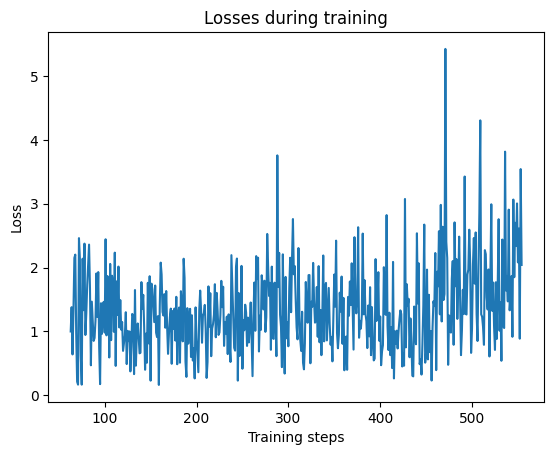

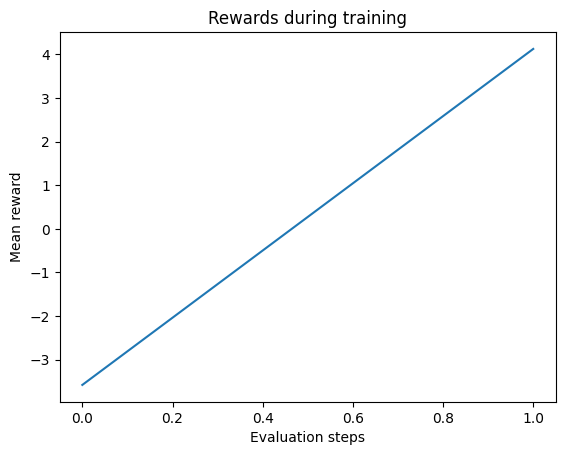

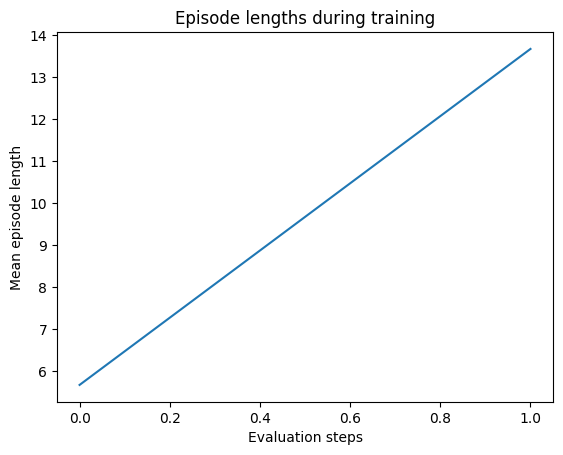


mean reward after training = 3.25 with average length 9.60


In [3]:
from highway.models.dqn.dqn import DQN
from highway.scripts.seed import set_seed
from highway.models.dqn.train import train

seed = 1
set_seed(seed)

env = get_env(seed=seed)

action_space = env.action_space
observation_space = env.observation_space

gamma = 0.9
batch_size = 64
buffer_capacity = 10_000
update_target_every = 200

epsilon_start = 0.95
decrease_epsilon_factor = 50
epsilon_min = 0.05

learning_rate = 5e-4

arguments = (action_space,
            observation_space,
            gamma,
            batch_size,
            buffer_capacity,
            update_target_every, 
            epsilon_start, 
            decrease_epsilon_factor, 
            epsilon_min,
            learning_rate,
        )

N_episodes = 2000

agent = DQN(*arguments)


# Run the training loop
losses, all_rewards, all_lengths, best_model_state = train(env, agent, N_episodes, eval_every=25, seed=seed)

plt.plot(losses)
plt.title("Losses during training")
plt.xlabel("Training steps")
plt.ylabel("Loss")
plt.show()

plt.plot(all_rewards)
plt.title("Rewards during training")
plt.xlabel("Evaluation steps")
plt.ylabel("Mean reward")
plt.show()

plt.plot(all_lengths)
plt.title("Episode lengths during training")
plt.xlabel("Evaluation steps")
plt.ylabel("Mean episode length")
plt.show()

# Evaluate the final policy
rewards, lengths = eval_agent(env, agent, 5)
print("")
print(f"mean reward after training = {np.mean(rewards):.2f} with average length {np.mean(lengths):.2f}")

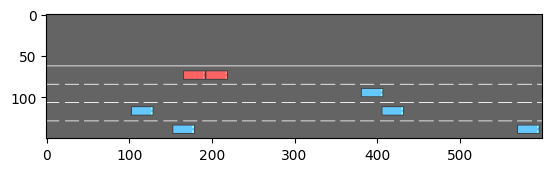

Episode reward=12.83, length=19


(np.float64(12.832883714516345), 19)

In [6]:
# Pour l'instant, il adopte la stratégie de ne pas changer de voie et d'aller lentement...
env = get_env()
run_one_episode(env, agent, display=True)

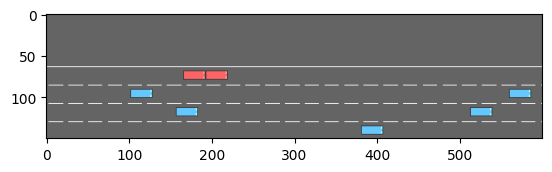

Episode reward=25.29, length=29


(np.float64(25.287161768018308), 29)

In [29]:
from highway.scripts.run import run_one_episode
from highway.models.dqn.dqn import DQN
import torch
import os

env = get_env(config_type=ConfigType.SHARED_CORE)

action_space = env.action_space
observation_space = env.observation_space

gamma = 0.99
batch_size = 64
buffer_capacity = 10_000
update_target_every = 200

epsilon_start = 0.95
decrease_epsilon_factor = 200
epsilon_min = 0.05

learning_rate = 1e-3

arguments = (action_space,
            observation_space,
            gamma,
            batch_size,
            buffer_capacity,
            update_target_every, 
            epsilon_start, 
            decrease_epsilon_factor, 
            epsilon_min,
            learning_rate,
        )

N_episodes = 1000

agent = DQN(*arguments)
date_str = "20260408_204324" # 20260408_204324, 20260408_212119, 20260408_232053
agent.q_net.load_state_dict(torch.load(os.path.join("model_weights", f"dqn_best_model_{date_str}.pth")))

run_one_episode(env, agent, display=True)

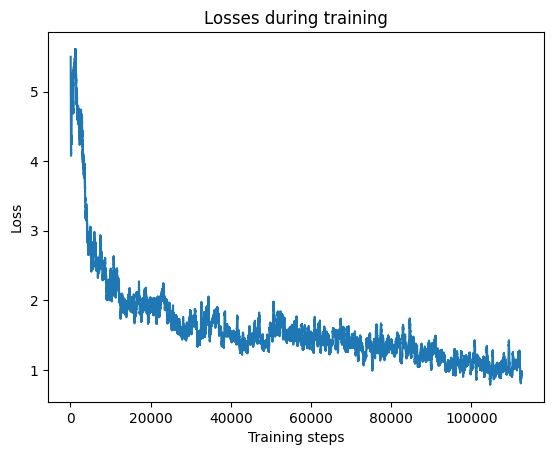

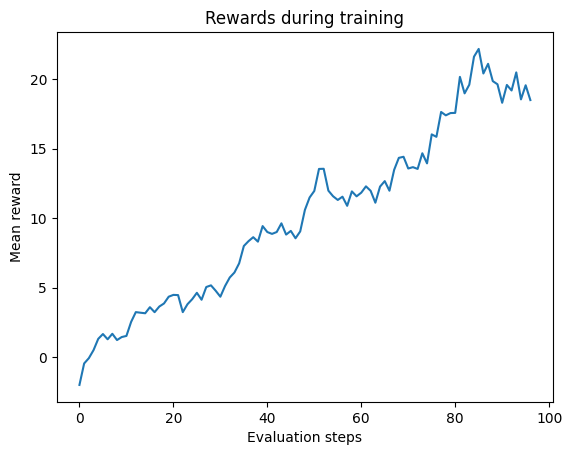

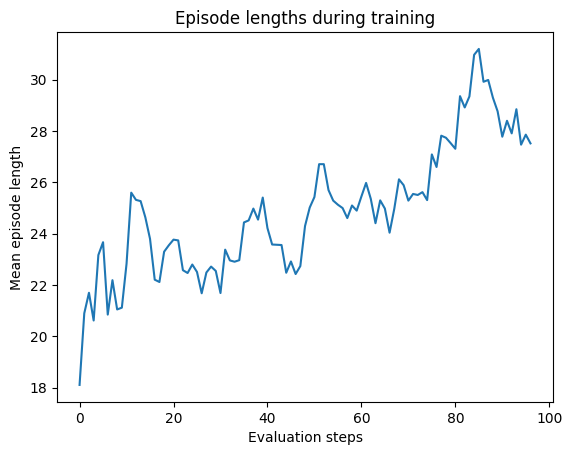

In [28]:
losses = np.load(os.path.join("results", f"dqn_losses_{date_str}.npy"))

smooth_losses = np.convolve(losses, np.ones(200)/200, mode='valid')
plt.plot(smooth_losses)
plt.title("Losses during training")
plt.xlabel("Training steps")
plt.ylabel("Loss")
plt.show()

rewards = np.load(os.path.join("results", f"dqn_rewards_{date_str}.npy"))
smooth_rewards = np.convolve(rewards, np.ones(5)/5, mode='valid')
plt.plot(smooth_rewards)
plt.title("Rewards during training")
plt.xlabel("Evaluation steps")
plt.ylabel("Mean reward")
plt.show()

lengths = np.load(os.path.join("results", f"dqn_lengths_{date_str}.npy"))
smooth_lengths = np.convolve(lengths, np.ones(5)/5, mode='valid')
plt.plot(smooth_lengths)
plt.title("Episode lengths during training")
plt.xlabel("Evaluation steps")
plt.ylabel("Mean episode length")
plt.show()